# Week 04 - ML/DL 기초 실습

In [57]:
import os
os.environ["MPLCONFIGDIR"] = os.path.join(os.getcwd(), ".matplotlib_cache")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 1. 가상 데이터셋 생성 & 학습/검증/테스트 분할

In [58]:
X, y = make_classification(n_samples=1000, n_features=10, random_state=42)

# 학습(60%) / 검증(20%) / 테스트(20%) 분할
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f'학습셋: {X_train.shape[0]}개')
print(f'검증셋: {X_val.shape[0]}개')
print(f'테스트셋: {X_test.shape[0]}개')

학습셋: 600개
검증셋: 200개
테스트셋: 200개


## 2. K-최근접이웃(K-NN) 학습 & 예측

In [59]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
print(f'K-NN 정확도: {accuracy_score(y_test, y_pred):.4f}')

K-NN 정확도: 0.8450


## 3. 이진 분류 - Perceptron / SVM / Random Forest / Naive Bayes 비교

In [60]:
from sklearn.linear_model import Perceptron
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

models = {
    'Perceptron': Perceptron(max_iter=1000, random_state=42),
    'SVM': SVC(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Naive Bayes': GaussianNB()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f'{name:15s} 정확도: {acc:.4f}')

Perceptron      정확도: 0.8050
SVM             정확도: 0.8650
Random Forest   정확도: 0.8750
Naive Bayes     정확도: 0.8450


## 4. Data Augmentation 적용 전/후 모델 성능 비교

In [61]:
# 작은 데이터셋으로 차이를 부각
X_small, y_small = make_classification(n_samples=100, n_features=10, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X_small, y_small, test_size=0.3, random_state=42)

# Augmentation: 학습 데이터에 약간의 가우시안 노이즈 추가
noise = np.random.normal(0, 0.1, X_tr.shape)
X_tr_aug = np.vstack([X_tr, X_tr + noise])
y_tr_aug = np.hstack([y_tr, y_tr])

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_tr, y_tr)
acc_before = accuracy_score(y_te, rf.predict(X_te))

rf.fit(X_tr_aug, y_tr_aug)
acc_after = accuracy_score(y_te, rf.predict(X_te))

print(f'증강 전 정확도: {acc_before:.4f}')
print(f'증강 후 정확도: {acc_after:.4f}')

증강 전 정확도: 0.9333
증강 후 정확도: 0.9667


## 5. 활성화 함수 정의 & 시각화

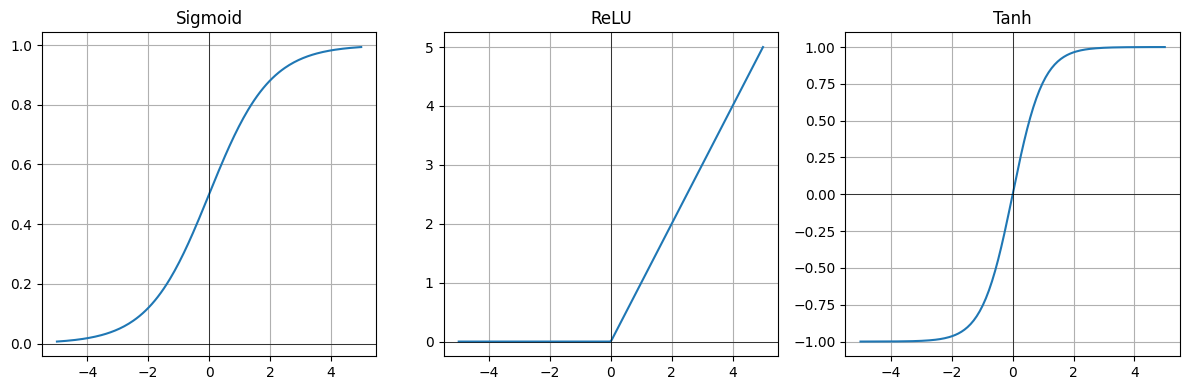

In [62]:
x = np.linspace(-5, 5, 200)

def sigmoid(x): return 1 / (1 + np.exp(-x))
def relu(x):    return np.maximum(0, x)
def tanh(x):    return np.tanh(x)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (name, fn) in zip(axes, [('Sigmoid', sigmoid), ('ReLU', relu), ('Tanh', tanh)]):
    ax.plot(x, fn(x))
    ax.set_title(name)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.axvline(0, color='k', linewidth=0.5)
    ax.grid(True)

plt.tight_layout()
plt.show()

## 6. MLP(다층 퍼셉트론) - 비선형 데이터 분류

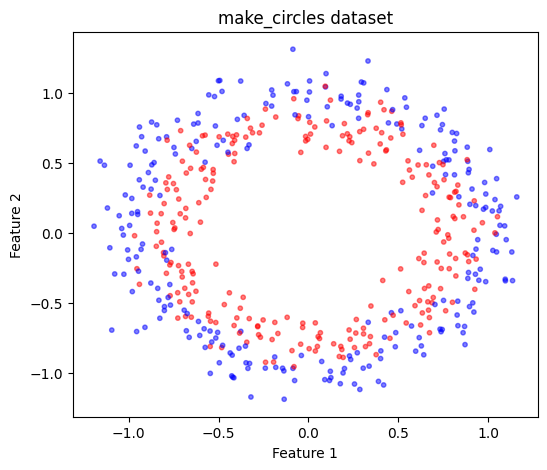

MLP 정확도: 0.8400


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [63]:
from sklearn.neural_network import MLPClassifier

# 비선형 데이터 (동심원)
X_nl, y_nl = make_circles(n_samples=500, noise=0.1, random_state=42)
X_nl_train, X_nl_test, y_nl_train, y_nl_test = train_test_split(X_nl, y_nl, test_size=0.2, random_state=42)

# 데이터 시각화
plt.figure(figsize=(6, 5))
plt.scatter(X_nl[:, 0], X_nl[:, 1], c=y_nl, cmap='bwr', alpha=0.5, s=10)
plt.title('make_circles dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

mlp = MLPClassifier(hidden_layer_sizes=(16, 8), activation='relu', max_iter=500, random_state=42)
mlp.fit(X_nl_train, y_nl_train)

acc = accuracy_score(y_nl_test, mlp.predict(X_nl_test))
print(f'MLP 정확도: {acc:.4f}')

## 7. CNN - 이미지 분류 (합성 데이터)

Epoch  2 | Train Loss: 1.0394 | Val Loss: 1.0056 | Val Acc: 0.5556
Epoch  4 | Train Loss: 0.8660 | Val Loss: 0.8412 | Val Acc: 0.6667
Epoch  6 | Train Loss: 0.7220 | Val Loss: 0.6942 | Val Acc: 0.7500
Epoch  8 | Train Loss: 0.6043 | Val Loss: 0.6138 | Val Acc: 0.7500
Epoch 10 | Train Loss: 0.5414 | Val Loss: 0.5434 | Val Acc: 0.8056

CNN Test Accuracy: 0.7778


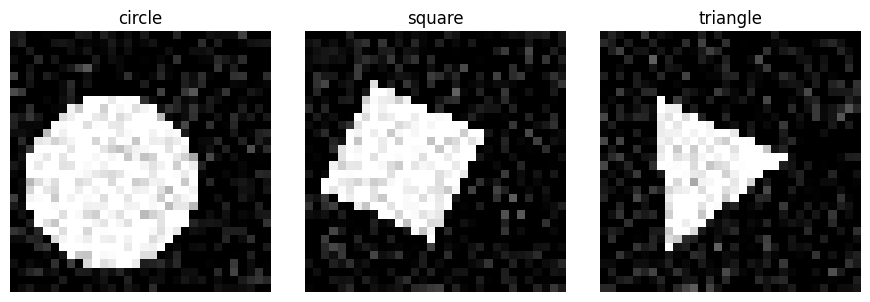

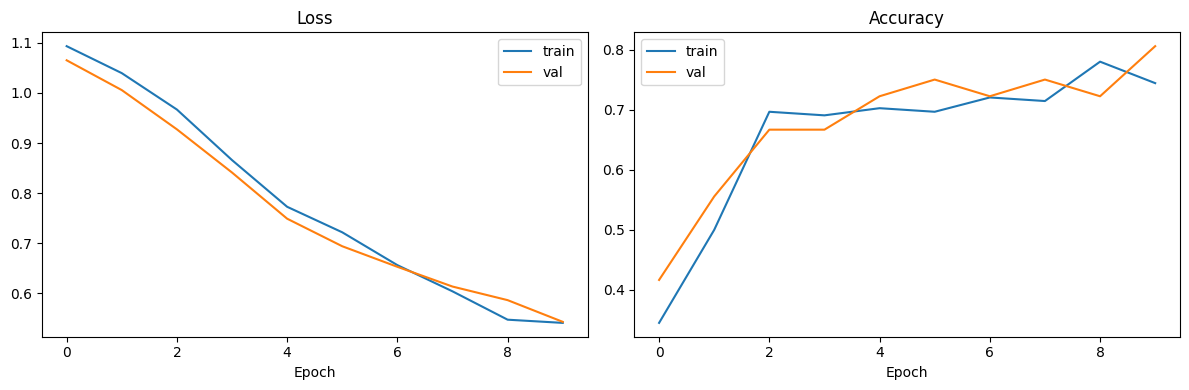

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

# 합성 이미지 데이터: 원 / 사각형 / 삼각형 3개 클래스 분류
torch.manual_seed(42)
rng = np.random.default_rng(seed=42)

IMAGE_SIZE = 32
SAMPLES_PER_CLASS = 80
NUM_CLASSES = 3
BATCH_SIZE = 32
EPOCHS = 10

label_names = ["circle", "square", "triangle"]


def create_shape_image(label):
    image = Image.new("L", (IMAGE_SIZE, IMAGE_SIZE), color=0)
    draw = ImageDraw.Draw(image)

    center = IMAGE_SIZE // 2
    center_x = int(center + rng.integers(-4, 5))
    center_y = int(center + rng.integers(-4, 5))
    radius = int(rng.integers(8, 12))
    rotation = float(rng.integers(0, 360))

    if label == 0:
        draw.ellipse(
            (center_x - radius, center_y - radius, center_x + radius, center_y + radius),
            fill=255
        )
    elif label == 1:
        draw.regular_polygon(
            (center_x, center_y, radius),
            n_sides=4,
            rotation=rotation,
            fill=255
        )
    else:
        draw.regular_polygon(
            (center_x, center_y, radius),
            n_sides=3,
            rotation=rotation,
            fill=255
        )

    image = np.array(image, dtype=np.float32) / 255.0
    noise = rng.normal(loc=0, scale=30 / 255, size=image.shape)

    return np.clip(image + noise, 0, 1)


images = []
labels = []

for label in range(NUM_CLASSES):
    for _ in range(SAMPLES_PER_CLASS):
        images.append(create_shape_image(label))
        labels.append(label)

images = np.array(images, dtype=np.float32)
labels = np.array(labels, dtype=np.int64)

X_train_img, X_temp_img, y_train_img, y_temp_img = train_test_split(
    images,
    labels,
    test_size=0.3,
    stratify=labels,
    random_state=42
)

X_val_img, X_test_img, y_val_img, y_test_img = train_test_split(
    X_temp_img,
    y_temp_img,
    test_size=0.5,
    stratify=y_temp_img,
    random_state=42
)


def make_loader(X, y, shuffle=False):
    X_tensor = torch.tensor(X[:, None, :, :], dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.long)
    dataset = TensorDataset(X_tensor, y_tensor)
    generator = torch.Generator().manual_seed(42)

    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        generator=generator if shuffle else None
    )


train_loader = make_loader(X_train_img, y_train_img, shuffle=True)
val_loader = make_loader(X_val_img, y_val_img)
test_loader = make_loader(X_test_img, y_test_img)


class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 8 * 8, 32),
            nn.ReLU(),
            nn.Linear(32, NUM_CLASSES)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = SimpleCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


def train_one_epoch(model, dataloader):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in dataloader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(y_batch)
        correct += (outputs.argmax(dim=1) == y_batch).sum().item()
        total += len(y_batch)

    return total_loss / total, correct / total


def evaluate(model, dataloader):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            total_loss += loss.item() * len(y_batch)
            correct += (outputs.argmax(dim=1) == y_batch).sum().item()
            total += len(y_batch)

    return total_loss / total, correct / total


train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(EPOCHS):
    train_loss, train_accuracy = train_one_epoch(model, train_loader)
    val_loss, val_accuracy = evaluate(model, val_loader)

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    if (epoch + 1) % 2 == 0:
        print(
            f"Epoch {epoch + 1:2d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )


test_loss, test_accuracy = evaluate(model, test_loader)
print()
print(f"CNN Test Accuracy: {test_accuracy:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(9, 3))

for label, ax in enumerate(axes):
    sample_index = np.where(labels == label)[0][0]
    ax.imshow(images[sample_index], cmap="gray", vmin=0, vmax=1)
    ax.set_title(label_names[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label="train")
axes[0].plot(val_losses, label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(train_accuracies, label="train")
axes[1].plot(val_accuracies, label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()
